# Demo: BioTuring Logo Warp

This demo shows how to use `warp_transform()` with the **zarr-on-disk** API.

## How to run
1. Make sure dependencies are installed: `uv sync` (or `pip install zarr opencv-python matplotlib numpy`)
2. Start the notebook from the **repo root** so that `bioturing_input.png` is found
3. Run cells top to bottom

## What it does
- **Input**: `bioturing_input.png` (RGB image, H x W x 3) — converted to `[C, H, W]` and written to a zarr store on disk
- **Transform**: Composed — Affine (rotate + scale) then TPS (wave distortion)
- **Output**: Per-channel zarr stores under `output_zarr/`, read back and composited for display

In [1]:
import os
import shutil

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import zarr

from spatialx_transform import warp_transform
from spatialx_transform.transforms import Affine, TPS, Composed
from spatialx_transform.params import AffineParams, TPSParams, ComposedParams

REPO_ROOT = os.path.abspath(os.getcwd())
print(f"REPO_ROOT: {REPO_ROOT}")

REPO_ROOT: /home/quan.lt/scratch/spatialx-transform


## 1. Prepare input zarr store

`warp_transform` reads input from a **zarr store on disk** (a directory path), not a numpy array. Here we load the PNG, convert to `[C, H, W]`, and write it to `input.zarr`.

In [2]:
INPUT_DIR = os.path.join(REPO_ROOT, "input.zarr")
OUTPUT_DIR = os.path.join(REPO_ROOT, "output_zarr")

# Clean up any previous run
for d in [INPUT_DIR, OUTPUT_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)

# Load logo: cv2 reads as [H, W, 3] BGR
img_bgr = cv.imread(os.path.join(REPO_ROOT, "bioturing_input.png"))
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Convert to [C, H, W] for warp_transform
img_chw = np.transpose(img_rgb, (2, 0, 1))
print(f"Input shape: {img_chw.shape}, dtype: {img_chw.dtype}")

# Write to zarr store on disk
z_in = zarr.create_array(
    store=INPUT_DIR,
    shape=img_chw.shape,
    chunks=(1, 512, 512),
    dtype=img_chw.dtype,
    fill_value=0,
    overwrite=True,
)
z_in[:] = img_chw
print(f"Wrote input zarr to {INPUT_DIR}")

Input shape: (3, 2500, 5000), dtype: uint8
Wrote input zarr to /home/quan.lt/scratch/spatialx-transform/input.zarr


## 2. Build the composed transform

Two sub-transforms applied in order:
1. **Affine** — rotate 10° and scale 1.1×
2. **TPS** — wave distortion via control points with alternating weights

In [3]:
# --- Transform 1: Affine (rotate 10deg + scale 1.1x) ---
angle = 10 * np.pi / 180
s = 1.1
A = [[s * np.cos(angle), -s * np.sin(angle)], [s * np.sin(angle), s * np.cos(angle)]]
affine_tf = Affine(params=AffineParams(A=A, b=[0.0, 0.0]))

# --- Transform 2: TPS (wave distortion) ---
# Control points spread across the image (x=col, y=row)
control_points = [
    500,
    500,
    2500,
    500,
    4500,
    500,
    500,
    1250,
    2500,
    1250,
    4500,
    1250,
    500,
    2000,
    2500,
    2000,
    4500,
    2000,
]
# Alternating weights create a wavy ripple effect
weights_x = [1.5e-5, -1.5e-5, 1.5e-5, -1.5e-5, 2.0e-5, -1.5e-5, 1.5e-5, -1.5e-5, 1.5e-5]
weights_y = [
    -0.8e-5,
    0.8e-5,
    -0.8e-5,
    0.8e-5,
    -1.0e-5,
    0.8e-5,
    -0.8e-5,
    0.8e-5,
    -0.8e-5,
]
tps_tf = TPS(
    params=TPSParams(
        affine_params=AffineParams(A=[[1.0, 0.0], [0.0, 1.0]], b=[0.0, 0.0]),
        weights_x=weights_x,
        weights_y=weights_y,
        control_points=control_points,
    )
)

# --- Composed: apply affine first, then TPS wave ---
tf = Composed(params=ComposedParams(transforms=[affine_tf, tps_tf]))
print(f"Composed transform: {len(tf.params.transforms)} sub-transforms")

Composed transform: 2 sub-transforms


## 3. Run warp_transform

Key parameters:
- `input_dir` / `output_dir`: paths to zarr stores on disk
- `d`: grid step for triangle mesh approximation (smaller = more accurate, slower)
- `chunk_size`: source-image chunk size for streaming (controls memory usage)
- `scale`: downscale/upscale factor for the output

The result is a `TransformationResult` with:
- `img_shape`: output shape `[C, H_dst, W_dst]`
- `img_zarr_list`: list of per-channel zarr arrays (lazy, on disk)
- `offset`: `(offsetX, offsetY)` of the warped bbox

In [4]:
result = warp_transform(
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    tf=tf,
    d=(20, 20),
    scale=(1.0, 1.0),
    chunk_size=(100, 100),
)
print(f"Output img_shape: {result.img_shape}")
print(f"Offset: {result.offset}")
print(f"Number of output zarr arrays: {len(result.img_zarr_list)}")
for ch, za in enumerate(result.img_zarr_list):
    print(f"  channel {ch}: shape={za.shape} dtype={za.dtype}")

Output img_shape: [3, 3646, 5902]
Offset: (-1288, 2205)
Number of output zarr arrays: 3
  channel 0: shape=(3646, 5902) dtype=uint8
  channel 1: shape=(3646, 5902) dtype=uint8
  channel 2: shape=(3646, 5902) dtype=uint8


## 4. Display result

Read each output channel back from disk and stack into an HWC image for display.

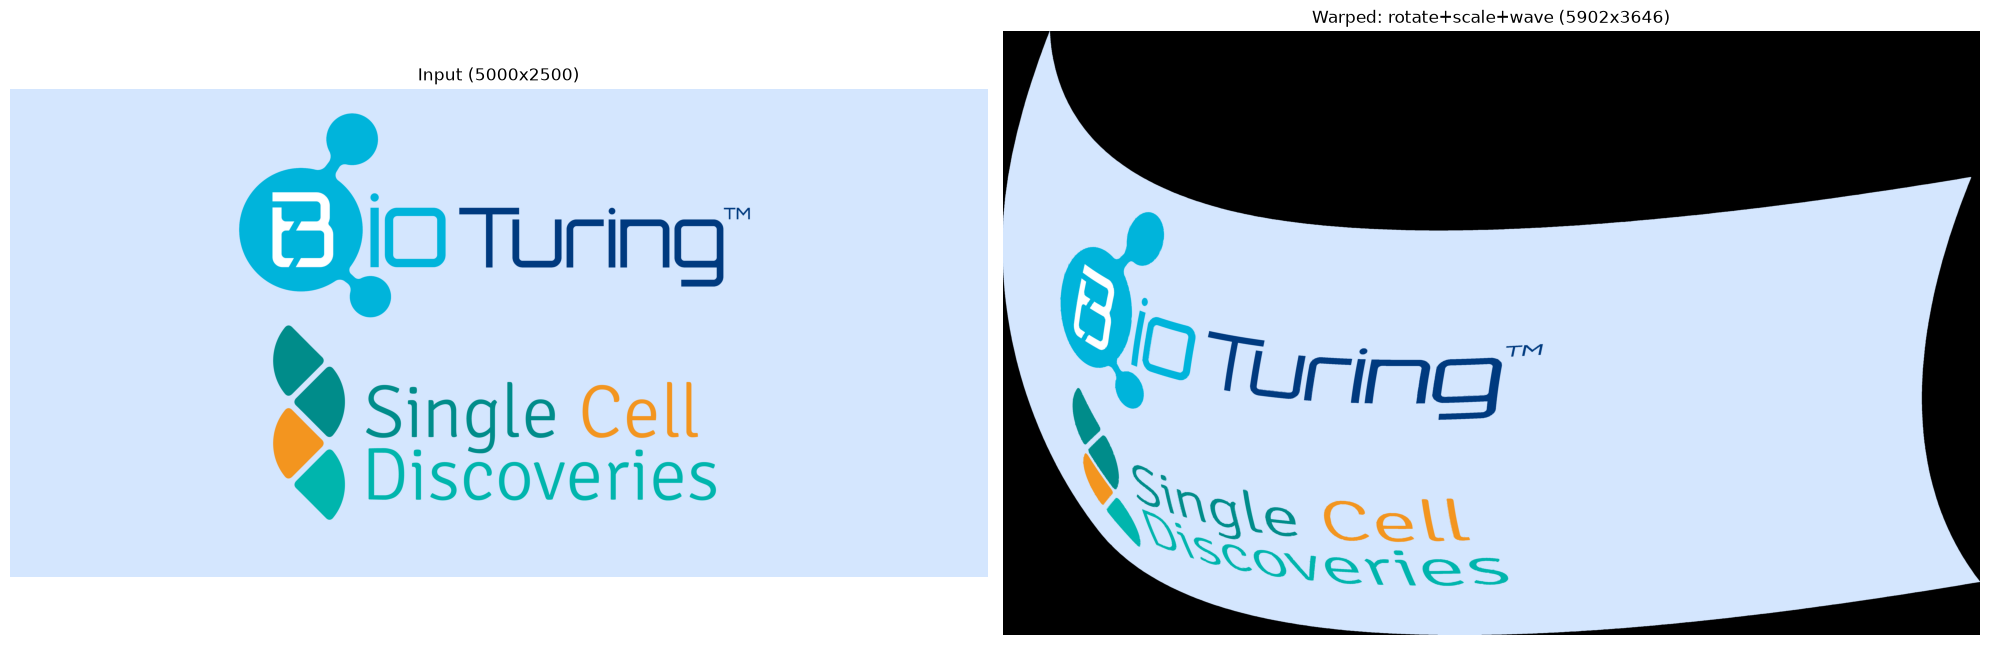

In [5]:
# Read output channels from disk and convert to HWC for display
num_channels = len(result.img_zarr_list)
output_chw = np.stack(
    [np.asarray(result.img_zarr_list[ch]) for ch in range(num_channels)]
)
output_rgb = np.transpose(output_chw, (1, 2, 0))

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(img_rgb)
axes[0].set_title(f"Input ({img_rgb.shape[1]}x{img_rgb.shape[0]})")
axes[0].axis("off")
axes[1].imshow(output_rgb)
axes[1].set_title(
    f"Warped: rotate+scale+wave ({output_rgb.shape[1]}x{output_rgb.shape[0]})"
)
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 5. Clean up

Remove the temporary input and output zarr stores. Keep only the in-memory display above.

In [6]:
for d in [INPUT_DIR, OUTPUT_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
        print(f"Deleted {d}")

Deleted /home/quan.lt/scratch/spatialx-transform/input.zarr
Deleted /home/quan.lt/scratch/spatialx-transform/output_zarr
